In [1]:
import io
import os
import time

import Levenshtein
from PIL import Image, ImageEnhance
from azure.cognitiveservices.vision.computervision import ComputerVisionClient
from azure.cognitiveservices.vision.computervision.models import OperationStatusCodes
from msrest.authentication import CognitiveServicesCredentials
from spellchecker import SpellChecker

'''
Authenticate
Authenticates your credentials and creates a client.
'''
subscription_key = os.environ["VISION_KEY"]
endpoint = os.environ["VISION_ENDPOINT"]
computervision_client = ComputerVisionClient(endpoint, CognitiveServicesCredentials(subscription_key))
'''
END - Authenticate
'''

# img = open("data/images/test1.png", "rb")
img = open("data/images/test2.jpeg", "rb")
read_response = computervision_client.read_in_stream(
    image=img,
    mode="Printed",
    raw=True
)
# print(read_response.as_dict())

operation_id = read_response.headers['Operation-Location'].split('/')[-1]
while True:
    read_result = computervision_client.get_read_result(operation_id)
    if read_result.status not in ['notStarted', 'running']:
        break
    time.sleep(1)

# Print the detected text, line by line
result = []
if read_result.status == OperationStatusCodes.succeeded:
    for text_result in read_result.analyze_result.read_results:
        for line in text_result.lines:
            # print(line.text)
            result.append(line.text)


recognized_text = " ".join(result)
recognized_words = recognized_text.split()
print(recognized_text)
ground_truth_text = "Succes în rezolvarea tEMELOR la LABORAtoarele de Inteligență Aritificială!"
ground_truth_words = ground_truth_text.split()

Lucces in resolvarea TEMELOR la LABORA toarele de Inteligenta Artificialà!


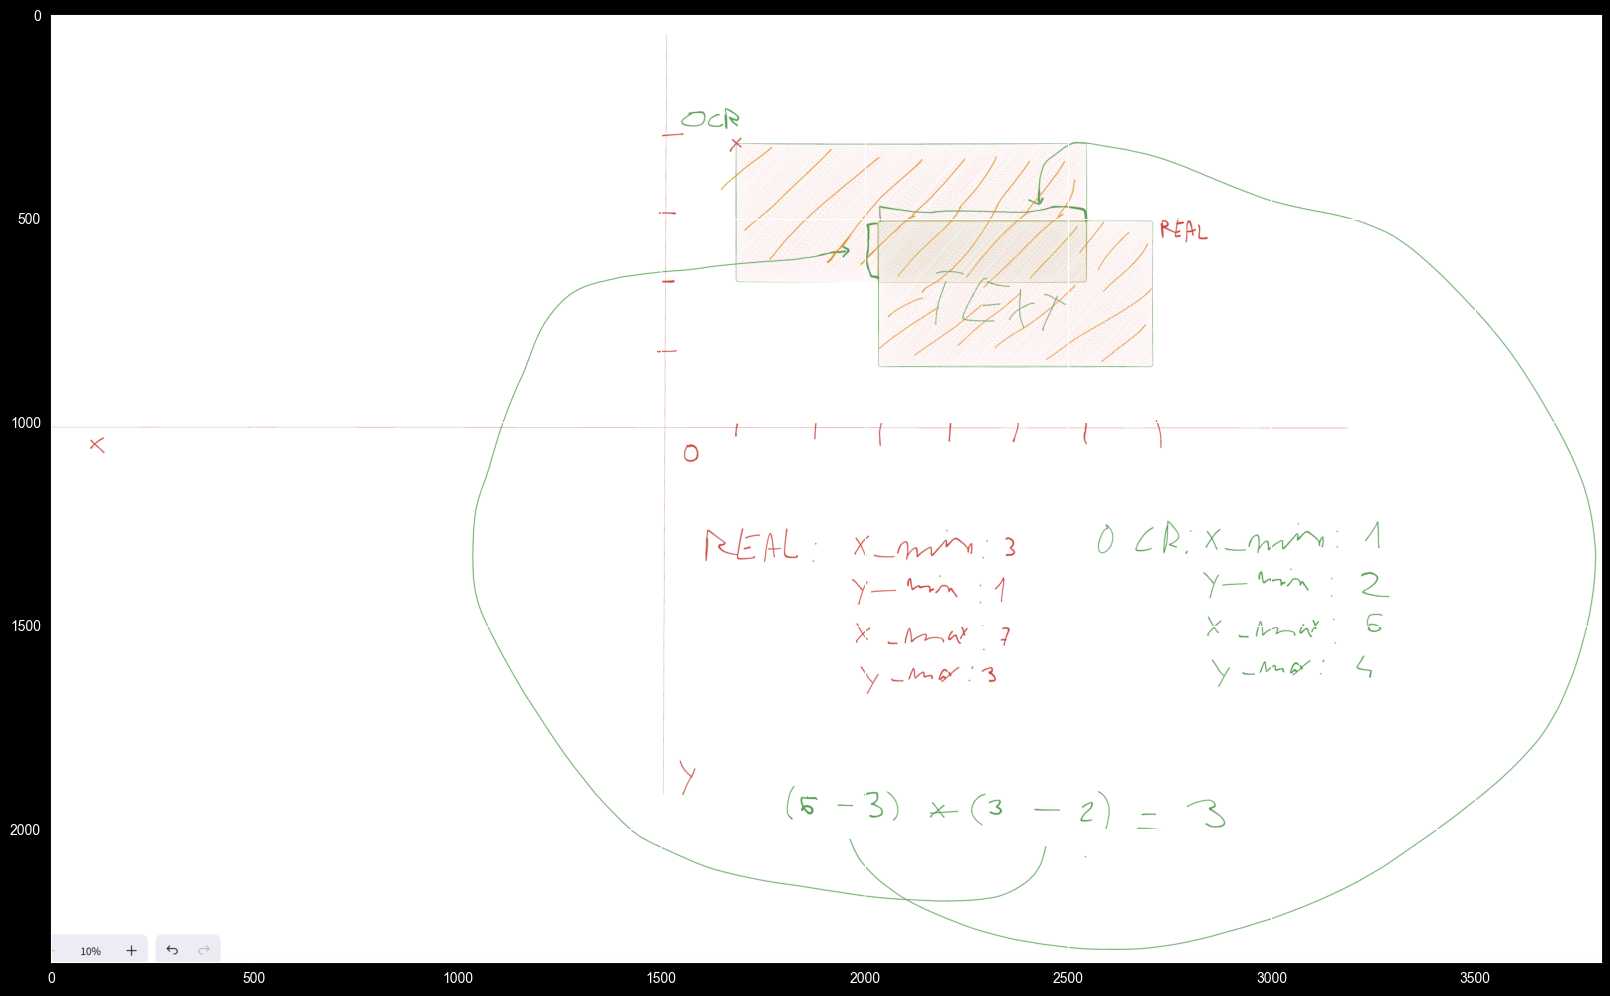

In [11]:
from matplotlib import pyplot as plt
from PIL import Image

img = Image.open("data/images/Screenshot 2026-03-17 at 17.28.15.png")
plt.figure(figsize=(20,20))
plt.imshow(img)
plt.show()

In [2]:
def cerinta2():
    # Take the coordinates of the bounding box for the recognized text
    def bounding_box_total_text():
        all_x = []
        all_y = []

        for text_result in read_result.analyze_result.read_results:
            for line in text_result.lines:
                coords = line.bounding_box  # [x1,y1,x2,y2,x3,y3,x4,y4]
                x_coords = coords[0::2]
                y_coords = coords[1::2]
                all_x.extend(x_coords)
                all_y.extend(y_coords)

        x_min = min(all_x)
        y_min = min(all_y)
        x_max = max(all_x)
        y_max = max(all_y)

        # Bounding box-ul final în format [x_min, y_min, x_max, y_max]
        total_box = [x_min, y_min, x_max, y_max]
        return total_box

    # Calculate Intersection over Union between two bounding boxes.
    # boxA, boxB = [x_min, y_min, x_max, y_max]
    def iou(boxA, boxB):
        xA = max(boxA[0], boxB[0])
        yA = max(boxA[1], boxB[1])
        xB = min(boxA[2], boxB[2])
        yB = min(boxA[3], boxB[3])

        # aria intersectiei
        interArea = max(0, xB - xA) * max(0, yB - yA)

        # aria fiecarui box
        boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
        boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

        # IoU = interArea / (aria totala fara suprapunere dublată)
        iou = interArea / float(boxAArea + boxBArea - interArea)
        return iou

    ground_truth_box = [46, 297, 1454, 1370]  # x_min, y_min, x_max, y_max

    detected_box = bounding_box_total_text()
    iou_score = iou(detected_box, ground_truth_box)
    print("Bounding box for total text (detected):", detected_box)
    print("Ground truth bounding box:", ground_truth_box)
    print("IoU between detected and ground truth:", iou_score)

In [3]:
cerinta2()

Bounding box for total text (detected): [78.0, 287.0, 1450.0, 1293.0]
Ground truth bounding box: [46, 297, 1454, 1370]
IoU between detected and ground truth: 0.8963649816596087
